---
# **Volatility clustering**
---

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

Data = pd.read_csv("TOTF_trade_2014_2017.csv")
Data = Data.drop(columns='source_file')
# Filter the data to keep only rows with time before 15:00
Data = Data[Data['time'] < '15:00:00']

We extract returns from same day prices

In [97]:
def get_returns(Data, log_returns=True):
    prices = Data['trade.price'].values
    dates = Data['date'].values

    returns = np.ones_like(prices)* np.nan
    returns_frame = pd.DataFrame(columns=['date', 'time', 'return'])
    returns_frame['date'] = Data['date']
    returns_frame['time'] = Data['time']
    returns_frame['datetime'] = pd.to_datetime(returns_frame['date'] + ' ' + returns_frame['time'])
    for i in range(1, len(prices)):
        if dates[i] == dates[i-1]:  # Check if transactions are on the same day
            returns[i] = (prices[i] / prices[i-1])
        else:
            returns[i] = (np.nan)  # Mark returns across different days as NaN
    if log_returns:
         returns_frame['returns'] = np.log(np.array(returns))  # Adding 1 to avoid log(0)
    else:
         returns_frame['returns'] = np.array(returns)
    return returns_frame

In [98]:
dates = Data['date'].values
# Get the first day's date
first_day = dates[0]
first_day_returns = get_returns(Data[Data['date'] == first_day])

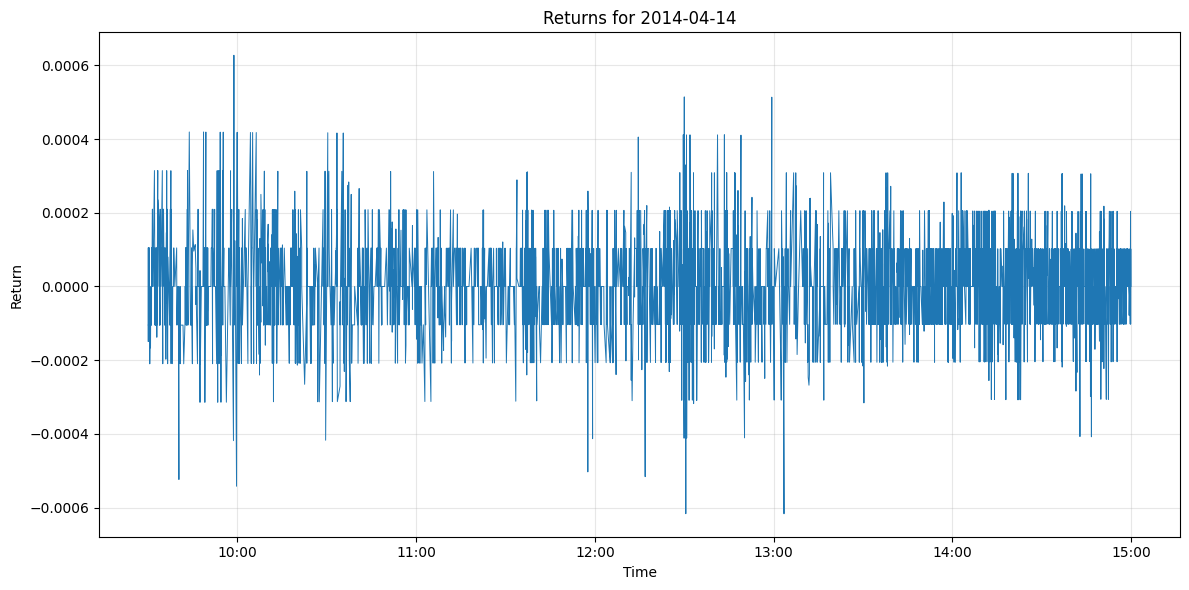

In [99]:
plt.figure(figsize=(12, 6))
plt.plot(first_day_returns['datetime'], first_day_returns['returns'], linewidth=0.7)
plt.title(f"Returns for {first_day}")
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xlabel("Time")
plt.ylabel("Return")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

We have way too many trading interactions to see significant returns.
Let's take 1 trade every minute and do the difference here.

In [100]:
# Create a new column with just the minute part of the time (hour:minute format)
Data['minute'] = Data['date'] + Data['time'].str.slice(0, 5)

# Group by the minute column and aggregate
# Mean price and summed volume for each minute
grouped = Data.groupby('minute').agg({
    'trade.price': 'mean',
    'trade.volume': 'sum'
})

# Reset index to make minute a column
grouped = grouped.reset_index()

# Extract date and time from the minute column
grouped['date'] = grouped['minute'].str[:10]
grouped['time'] = grouped['minute'].str[10:]

# Reorder columns to match original data
minute_Data = grouped[['date', 'time', 'trade.price', 'trade.volume']]

# Print the size of the original and filtered datasets
print(f"Original dataset size: {len(Data)} rows")
print(f"Filtered dataset size: {len(minute_Data)} rows")
print(f"Percentage of trades kept: {len(minute_Data) / len(Data) * 100:.2f}%")
print(minute_Data)

Original dataset size: 4016450 rows
Filtered dataset size: 250143 rows
Percentage of trades kept: 6.23%
              date   time  trade.price  trade.volume
0       2014-04-14  09:30    47.651193       10082.0
1       2014-04-14  09:31    47.644167        9080.0
2       2014-04-14  09:32    47.665920        7201.0
3       2014-04-14  09:33    47.674684        6218.0
4       2014-04-14  09:34    47.700500        2815.0
...            ...    ...          ...           ...
250138  2017-04-12  14:55    48.756763        8868.0
250139  2017-04-12  14:56    48.748519        8488.0
250140  2017-04-12  14:57    48.736218        8623.0
250141  2017-04-12  14:58    48.735625        2750.0
250142  2017-04-12  14:59    48.715833        6191.0

[250143 rows x 4 columns]


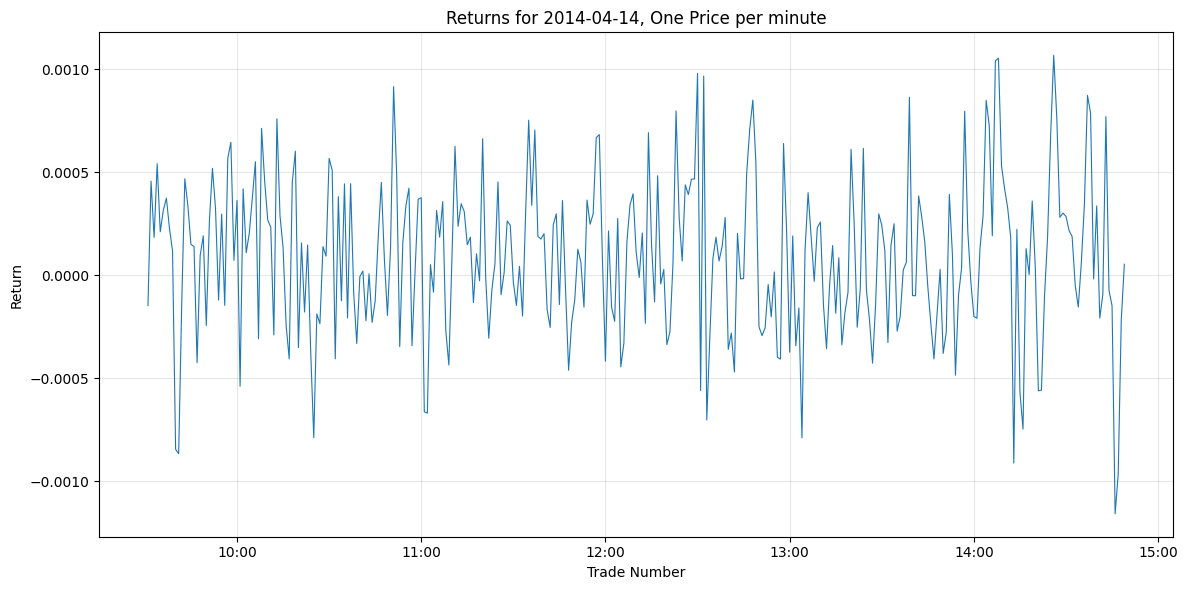

In [101]:
first_day_filtered_returns = get_returns(minute_Data[minute_Data['date'] == first_day]).iloc[:-10]

plt.figure(figsize=(12, 6))
plt.plot(first_day_filtered_returns['datetime'], first_day_filtered_returns['returns'], linewidth=0.8)
plt.title(f"Returns for {first_day}, One Price per minute")
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xlabel("Trade Number")
plt.ylabel("Return")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Autocorrelation data not found. Calculating from scratch...


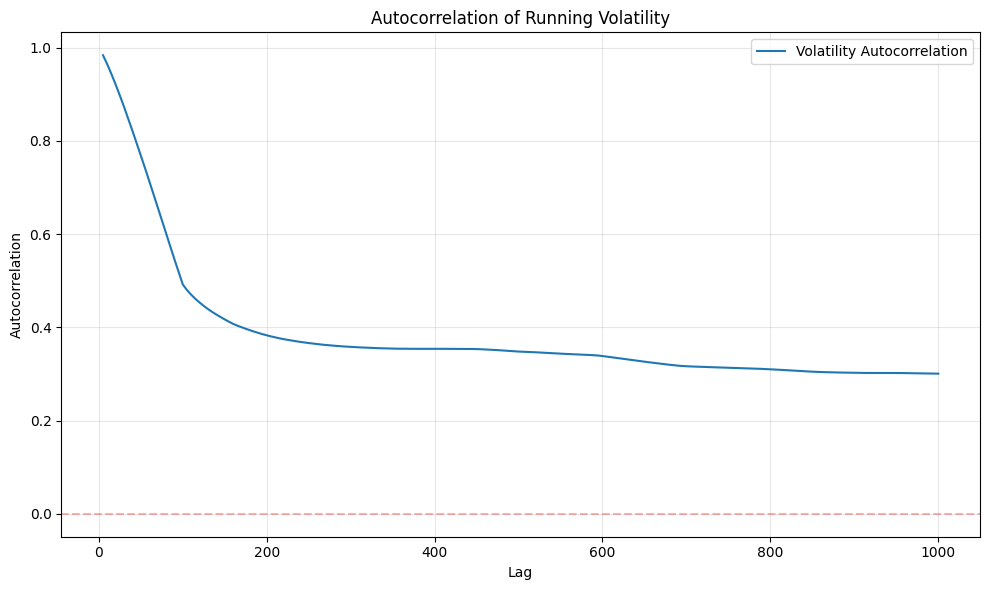

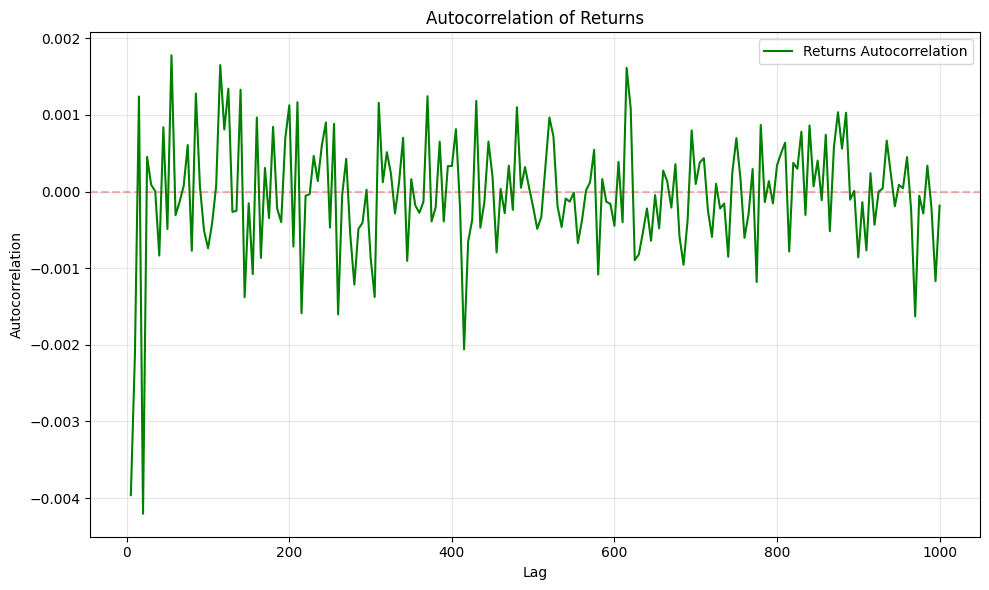

In [102]:
window_size = 100  # Adjust this based on your needs
max_lag = 1000  # Maximum lag to calculate
lag_step = 5
lag_range = range(lag_step, max_lag+1, lag_step)

try:
    # Add a unique identifier to avoid loading existing file
    autocorr_dataframe = pd.read_csv(f'csv_data/autocorrelation_volatility_window={window_size}_lagmax={max_lag}_lagstep={lag_step}.csv', index_col=0)
    print("Autocorrelation data already exists. Loading from file...")
except FileNotFoundError:
    print("Autocorrelation data not found. Calculating from scratch...")
    print("Calculating returns...", end='\r', flush=True)
    clean_returns = get_returns(Data)

    try:
        running_std = np.loadtxt(f'csv_data/running_std_window{window_size}.csv', delimiter=',')
        print("Running standard deviation data already exists. Loading from file...")
    except FileNotFoundError:
        print("Calculating running standard deviation...", end='\r', flush=True)
        # Calculate the running standard deviation on just the returns column
        running_std = []
        # Make sure we're dealing with numeric data
        returns_values = clean_returns['returns'].dropna().values
        
        length = len(returns_values) - window_size + 1
        previous_percentage = 0
        for i in range(0, len(returns_values)-window_size):
            percentage = int(i/length*100)
            running_std.append(np.std(returns_values[i:i+window_size]))
            if percentage != previous_percentage:
                print(f"Running std calculation : {percentage}%, running {i}/{length}", end='\r', flush=True)
                previous_percentage = percentage
        running_std = np.array(running_std)
        print(" " * 80, end='\r', flush=True)  # Clear the line
        print("Running standard deviation calculation complete.", end='\r', flush=True)
        np.savetxt(f'csv_data/running_std_window{window_size}.csv', running_std, delimiter=',')
    
    print(" " * 80, end='\r', flush=True)  # Clear the line
    print("Calculating autocorrelation...", end='\r', flush=True)
    # Calculate the autocorrelation of the running standard deviation
    autocorr_dataframe = pd.DataFrame(index=lag_range, columns=['autocorrelation', 'returns_autocorr'])
    vol_autocorr = []
    returns_autocorr = []
    
    # Get the returns values for calculating autocorrelation
    returns_values = clean_returns['returns'].dropna().values
    
    for lag in lag_range:
        # Volatility autocorrelation
        vol_autocorr.append(np.corrcoef(running_std[:-lag], running_std[lag:])[0,1])
        
        # Returns autocorrelation - could show negative values
        if lag < len(returns_values):
            returns_autocorr.append(np.corrcoef(returns_values[:-lag], returns_values[lag:])[0,1])
        else:
            returns_autocorr.append(np.nan)
            
        print(f"Autocorrelation for lag {lag}/{max_lag}", end='\r', flush=True)
    print(" " * 80, end='\r', flush=True)  # Clear the line
    print("Autocorrelation calculation complete.", end='\r', flush=True)
    
    autocorr_dataframe['autocorrelation'] = np.array(vol_autocorr)
    autocorr_dataframe['returns_autocorr'] = np.array(returns_autocorr)
    autocorr_dataframe.to_csv(f'csv_data/autocorrelation_volatility_window={window_size}_lagmax={max_lag}_lagstep={lag_step}.csv', index_label='lag')


# Plot the autocorrelation
plt.figure(figsize=(10, 6))
plt.plot(autocorr_dataframe.index, autocorr_dataframe['autocorrelation'], label='Volatility Autocorrelation')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)  # Add zero reference line
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation of Running Volatility')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Also plot returns autocorrelation if available
if 'returns_autocorr' in autocorr_dataframe.columns:
    plt.figure(figsize=(10, 6))
    plt.plot(autocorr_dataframe.index, autocorr_dataframe['returns_autocorr'], color='g', label='Returns Autocorrelation')
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)  # Add zero reference line
    plt.xlabel('Lag')
    plt.ylabel('Autocorrelation')
    plt.title('Autocorrelation of Returns')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

We try the same on the filtered data : 
one every minute

Filtered autocorrelation data not found. Calculating from scratch...


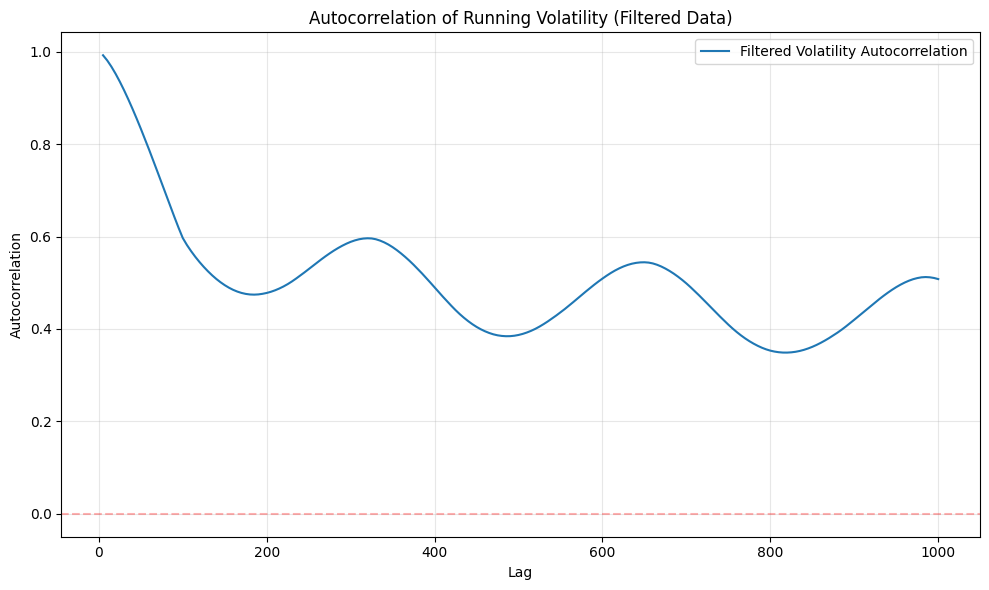

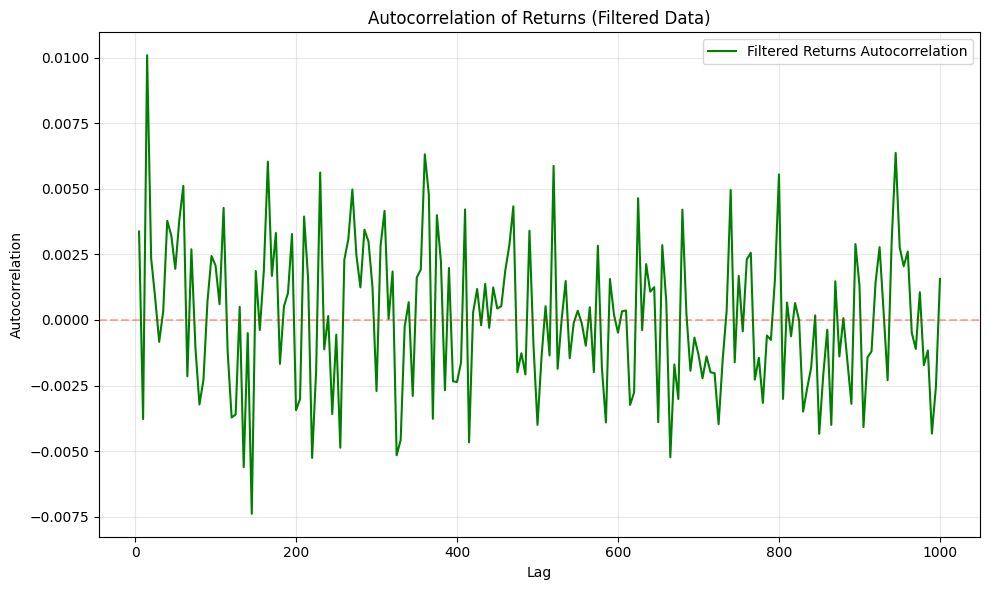

In [103]:
window_size = 100  # Adjust this based on your needs
max_lag = 1000  # Maximum lag to calculate
lag_step = 5
lag_range = range(lag_step, max_lag+1, lag_step)

try:
    autocorr_filtered_dataframe = pd.read_csv(f'csv_data/autocorrelation_filtered_window={window_size}_lagmax={max_lag}_lagstep={lag_step}.csv', index_col=0)
    print("Filtered autocorrelation data already exists. Loading from file...")
except FileNotFoundError:
    print("Filtered autocorrelation data not found. Calculating from scratch...")
    print("Calculating returns...", end='\r', flush=True)
    
    # Use the minute-filtered data instead of raw data
    clean_returns = get_returns(minute_Data)

    try:
        filtered_running_std = np.loadtxt(f'csv_data/filtered_running_std_window{window_size}.csv', delimiter=',')
        print("Filtered running standard deviation data already exists. Loading from file...")
    except FileNotFoundError:
        print("Calculating filtered running standard deviation...", end='\r', flush=True)
        # Calculate the running standard deviation on just the returns column
        filtered_running_std = []
        # Make sure we're dealing with numeric data
        returns_values = clean_returns['returns'].dropna().values
        
        length = len(returns_values) - window_size + 1
        previous_percentage = 0
        for i in range(0, len(returns_values)-window_size):
            percentage = int(i/length*100)
            filtered_running_std.append(np.std(returns_values[i:i+window_size]))
            if percentage != previous_percentage:
                print(f"Running std calculation : {percentage}%, running {i}/{length}", end='\r', flush=True)
                previous_percentage = percentage
        filtered_running_std = np.array(filtered_running_std)
        print(" " * 80, end='\r', flush=True)  # Clear the line
        print("Running standard deviation calculation complete.", end='\r', flush=True)
        np.savetxt(f'csv_data/filtered_running_std_window{window_size}.csv', filtered_running_std, delimiter=',')
    
    print(" " * 80, end='\r', flush=True)  # Clear the line
    print("Calculating autocorrelation...", end='\r', flush=True)
    # Calculate the autocorrelation of the running standard deviation
    autocorr_filtered_dataframe = pd.DataFrame(index=lag_range, columns=['autocorrelation', 'returns_autocorr'])
    vol_autocorr = []
    returns_autocorr = []
    
    # Get the returns values for calculating autocorrelation
    returns_values = clean_returns['returns'].dropna().values
    
    for lag in lag_range:
        # Volatility autocorrelation
        if lag < len(filtered_running_std):
            vol_autocorr.append(np.corrcoef(filtered_running_std[:-lag], filtered_running_std[lag:])[0,1])
        else:
            vol_autocorr.append(np.nan)
        
        # Returns autocorrelation - could show negative values
        if lag < len(returns_values):
            returns_autocorr.append(np.corrcoef(returns_values[:-lag], returns_values[lag:])[0,1])
        else:
            returns_autocorr.append(np.nan)
            
        print(f"Autocorrelation for lag {lag}/{max_lag}", end='\r', flush=True)
    print(" " * 80, end='\r', flush=True)  # Clear the line
    print("Autocorrelation calculation complete.", end='\r', flush=True)
    
    autocorr_filtered_dataframe['autocorrelation'] = np.array(vol_autocorr)
    autocorr_filtered_dataframe['returns_autocorr'] = np.array(returns_autocorr)
    autocorr_filtered_dataframe.to_csv(f'csv_data/autocorrelation_filtered_window={window_size}_lagmax={max_lag}_lagstep={lag_step}.csv', index_label='lag')


# Plot the volatility autocorrelation
plt.figure(figsize=(10, 6))
plt.plot(autocorr_filtered_dataframe.index, 
        autocorr_filtered_dataframe['autocorrelation'], label='Filtered Volatility Autocorrelation')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)  # Add zero reference line
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation of Running Volatility (Filtered Data)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Also plot returns autocorrelation if available
if 'returns_autocorr' in autocorr_filtered_dataframe.columns:
    plt.figure(figsize=(10, 6))
    plt.plot(autocorr_filtered_dataframe.index, autocorr_filtered_dataframe['returns_autocorr'], color='g', label='Filtered Returns Autocorrelation')
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)  # Add zero reference line
    plt.xlabel('Lag')
    plt.ylabel('Autocorrelation')
    plt.title('Autocorrelation of Returns (Filtered Data)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()